In [6]:
import os
import numpy as np
import pandas as pd
from glob import glob

# Dataset paths
BASE_DIR = "Dataset"
IMG_DIR = os.path.join(BASE_DIR, "images")
ANN_DIR = os.path.join(BASE_DIR, "annotations")

print("Image folder:", IMG_DIR)
print("Annotations folder:", ANN_DIR)


Image folder: Dataset\images
Annotations folder: Dataset\annotations


In [ ]:
def load_annotation(idx, ann_dir):
    """Load expression, valence, arousal for one image index"""
    exp_path = os.path.join(ann_dir, f"{idx}_exp.npy")
    val_path = os.path.join(ann_dir, f"{idx}_val.npy")
    aro_path = os.path.join(ann_dir, f"{idx}_aro.npy")
    
    # Loading values
    exp = np.load(exp_path, allow_pickle=True).item() if os.path.exists(exp_path) else None
    val = np.load(val_path, allow_pickle=True).item() if os.path.exists(val_path) else None
    aro = np.load(aro_path, allow_pickle=True).item() if os.path.exists(aro_path) else None
    
    return exp, val, aro


In [ ]:
# Collecting image files
image_files = sorted(glob(os.path.join(IMG_DIR, "*.jpg")))
print("Total images:", len(image_files))

records = []

for img_path in image_files:
    idx = os.path.splitext(os.path.basename(img_path))[0]  # "0", "1", "2" ...
    
    exp, val, aro = load_annotation(idx, ANN_DIR)
    
    if exp is not None and val is not None and aro is not None:
        records.append({
            "file": img_path,
            "expression": int(exp),
            "valence": float(val),
            "arousal": float(aro)
        })

# Create DataFrame
df = pd.DataFrame(records)

# Remove invalid valence/arousal = -2
df = df[(df["valence"] != -2) & (df["arousal"] != -2)]

print("Final dataset shape:", df.shape)
df.head()


Total images: 3999
Final dataset shape: (3999, 4)


,file,expression,valence,arousal
0,Dataset\images\0.jpg,0,-0.176846,-0.077640
1,Dataset\images\1.jpg,0,-0.367789,0.183895
2,Dataset\images\10.jpg,7,-0.648471,0.658149
3,Dataset\images\100.jpg,3,0.150794,0.666667
4,Dataset\images\1001.jpg,0,-0.135501,0.004839


In [9]:
df

,file,expression,valence,arousal
0,Dataset\images\0.jpg,0,-0.176846,-0.077640
1,Dataset\images\1.jpg,0,-0.367789,0.183895
2,Dataset\images\10.jpg,7,-0.648471,0.658149
3,Dataset\images\100.jpg,3,0.150794,0.666667
4,Dataset\images\1001.jpg,0,-0.135501,0.004839
...,...,...,...,...
3994,Dataset\images\992.jpg,5,-0.738095,0.436508
3995,Dataset\images\994.jpg,1,0.468254,0.119048
3996,Dataset\images\995.jpg,1,0.531746,0.015873
3997,Dataset\images\996.jpg,6,-0.416183,0.701703


In [10]:
# Save dataframe to CSV for later use
df.to_csv("cleaned_dataset.csv", index=False)
print("DataFrame saved as cleaned_dataset.csv")




DataFrame saved as cleaned_dataset.csv


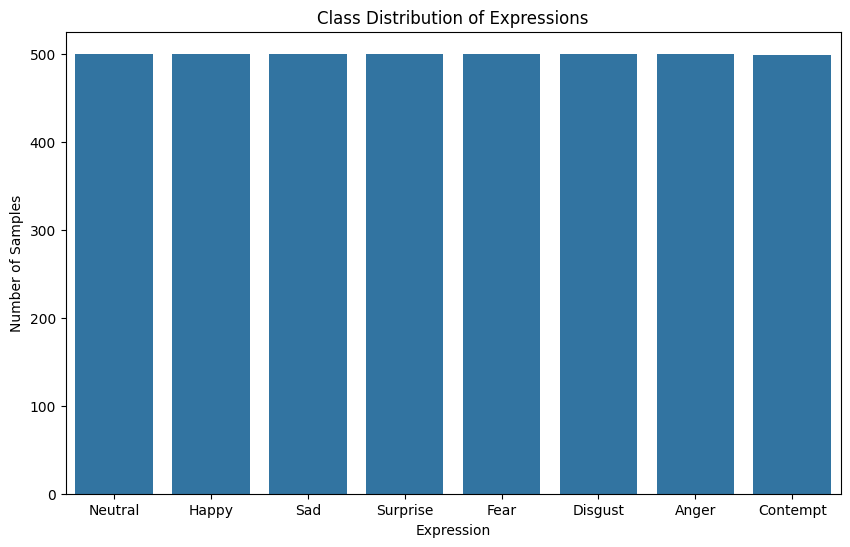

expression
0    500
1    500
2    500
3    500
4    500
5    500
6    500
7    499
Name: count, dtype: int64

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class distribution
class_counts = df["expression"].value_counts().sort_index()

# Expression labels mapping (based on assignment)
labels_map = {
    0: "Neutral", 
    1: "Happy", 
    2: "Sad", 
    3: "Surprise", 
    4: "Fear", 
    5: "Disgust", 
    6: "Anger", 
    7: "Contempt"
}

# Plot class distribution
plt.figure(figsize=(10,6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks(class_counts.index, [labels_map[i] for i in class_counts.index])
plt.title("Class Distribution of Expressions")
plt.xlabel("Expression")
plt.ylabel("Number of Samples")
plt.show()

class_counts


In [13]:
# Step 5 – Train/Val/Test Split
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["expression"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["expression"], random_state=42)

print("Train:", train_df.shape, " Val:", val_df.shape, " Test:", test_df.shape)


Train: (2799, 4)  Val: (600, 4)  Test: (600, 4)


In [14]:
# Step 6 – Data Preprocessing & Augmentation

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(rescale=1./255)


In [15]:
# Step 7 – TensorFlow tf.data Pipeline
import tensorflow as tf

IMG_SIZE = (224,224)

def process_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_crop(tf.image.resize_with_crop_or_pad(img, 240, 240), IMG_SIZE + (3,))
    return img, label

# Convert DataFrame to tf.data
train_paths = train_df["file"].values
train_labels = train_df["expression"].values

val_paths = val_df["file"].values
val_labels = val_df["expression"].values

test_paths = test_df["file"].values
test_labels = test_df["expression"].values

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(lambda x,y: process_image(x,y), num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1024).batch(32).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(lambda x,y: process_image(x,y), num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(lambda x,y: process_image(x,y), num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)


step 8

Imports and constants

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB0

# Constants
IMG_SIZE = (224,224)
BATCH_SIZE = 32
NUM_CLASSES = df["expression"].nunique()

print(" Libraries loaded. Image size:", IMG_SIZE, "| Classes:", NUM_CLASSES)


 Libraries loaded. Image size: (224, 224) | Classes: 8


In [21]:
# One-hot encoding for classification
df_class = df.copy()
df_class["expression_onehot"] = list(tf.keras.utils.to_categorical(df_class["expression"], NUM_CLASSES))

# Convert to numpy arrays for tf.data
expr_onehot = np.array(df_class["expression_onehot"].to_list())

# Replace original column with ndarray form
df_class["expression_onehot"] = list(expr_onehot)

print(" One-hot encoded labels prepared:", expr_onehot.shape)


 One-hot encoded labels prepared: (3999, 8)


In [22]:
# Classification datasets
train_ds_clf = tf.data.Dataset.from_tensor_slices(
    (train_df["file"].values, np.array(train_df["expression_onehot"].to_list()))
)
train_ds_clf = train_ds_clf.map(process_image).map(augment_image).shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds_clf = tf.data.Dataset.from_tensor_slices(
    (val_df["file"].values, np.array(val_df["expression_onehot"].to_list()))
)
val_ds_clf = val_ds_clf.map(process_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds_clf = tf.data.Dataset.from_tensor_slices(
    (test_df["file"].values, np.array(test_df["expression_onehot"].to_list()))
)
test_ds_clf = test_ds_clf.map(process_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Regression datasets (valence + arousal)
train_ds_reg = tf.data.Dataset.from_tensor_slices(
    (train_df["file"].values, train_df[["valence","arousal"]].values.astype("float32"))
)
train_ds_reg = train_ds_reg.map(process_image).map(augment_image).shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds_reg = tf.data.Dataset.from_tensor_slices(
    (val_df["file"].values, val_df[["valence","arousal"]].values.astype("float32"))
)
val_ds_reg = val_ds_reg.map(process_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(" tf.data pipelines fixed and ready")


 tf.data pipelines fixed and ready


step 9

In [32]:
from tensorflow.keras.applications import ResNet50
import os

def build_classification_model():
    # Clean cache if old/partial weight file exists
    cache_dir = os.path.expanduser("~/.keras/models/")
    weights_file = os.path.join(cache_dir, "resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5")
    if os.path.exists(weights_file):
        try:
            os.remove(weights_file)
            print(" Old/partial ResNet50 weights removed. Will re-download.")
        except Exception as e:
            print(" Could not remove cached weights:", e)

    # Load pretrained ResNet50
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )
    base.trainable = False   # freeze backbone

    inputs = layers.Input(shape=(224,224,3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)   # regularization
    outputs = layers.Dense(
        NUM_CLASSES, activation="softmax",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    model = models.Model(inputs, outputs, name="ResNet50_Classifier")
    return model

clf_model = build_classification_model()
clf_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

print(" ResNet50 classification model built successfully")
clf_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1916s 20us/step
 ResNet50 classification model built successfully


Model: "ResNet50_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        16,392 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,604,104 (90.04 MB)

 Trainable params: 16,392 (64.03 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [33]:
def build_regression_model():
    # Clean cache if old/partial weight file exists
    cache_dir = os.path.expanduser("~/.keras/models/")
    weights_file = os.path.join(cache_dir, "resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5")
    if os.path.exists(weights_file):
        try:
            os.remove(weights_file)
            print(" Old/partial ResNet50 weights removed. Will re-download.")
        except Exception as e:
            print("Could not remove cached weights:", e)

    # Load pretrained ResNet50
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )
    base.trainable = False

    inputs = layers.Input(shape=(224,224,3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(
        2, activation="tanh",   # valence & arousal in [-1,1]
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    model = models.Model(inputs, outputs, name="ResNet50_Regressor")
    return model

reg_model = build_regression_model()
reg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

print(" ResNet50 regression model built successfully")
reg_model.summary()


 Old/partial ResNet50 weights removed. Will re-download.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 709s 7us/step
 ResNet50 regression model built successfully


Model: "ResNet50_Regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [34]:
import tensorflow as tf
import math
import datetime

# Cosine Annealing Learning Rate Scheduler
def cosine_annealing(epoch, lr, initial_lr=1e-4, T_max=10):
    """Cosine Annealing schedule with warm restarts every T_max epochs"""
    return initial_lr * (1 + math.cos(math.pi * (epoch % T_max) / T_max)) / 2

# Directory for logs
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

callbacks = [
    # Stop training early if no improvement
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
    ),
    
    # Reduce LR if stuck
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1
    ),
    
    # Save best model
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.h5", save_best_only=True, monitor="val_loss", mode="min", verbose=1
    ),
    
    # TensorBoard for monitoring
    tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    
    # Cosine annealing LR schedule
    tf.keras.callbacks.LearningRateScheduler(cosine_annealing, verbose=0),
]

print("Callbacks ready with EarlyStopping, LR scheduling, Checkpointing, TensorBoard, and Cosine Annealing")


Callbacks ready with EarlyStopping, LR scheduling, Checkpointing, TensorBoard, and Cosine Annealing


In [ ]:
# === Cell 7: Train + Fine-tune + Evaluate + Plot (Classification & Regression) ===
import os, datetime, math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ---------- Safety: ensure cosine_annealing exists from Cell 6 ----------
if "cosine_annealing" not in globals():
    def cosine_annealing(epoch, lr, initial_lr=1e-4, T_max=10):
        return initial_lr * (1 + math.cos(math.pi * (epoch % T_max) / T_max)) / 2

# ---------- Build test_ds_reg if missing ----------
try:
    test_ds_reg
except NameError:
    test_ds_reg = tf.data.Dataset.from_tensor_slices(
        (test_df["file"].values, test_df[["valence","arousal"]].values.astype("float32"))
    )
    test_ds_reg = test_ds_reg.map(process_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    print(" Built test_ds_reg pipeline.")

# ---------- Per-task callbacks (separate logs & checkpoints) ----------
log_dir_root = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

def make_callbacks(tag):
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(f"best_{tag}.h5", save_best_only=True, monitor="val_loss", mode="min", verbose=1),
        tf.keras.callbacks.TensorBoard(log_dir=os.path.join(log_dir_root, tag), histogram_freq=1),
        tf.keras.callbacks.LearningRateScheduler(cosine_annealing, verbose=0),
    ]

callbacks_clf = make_callbacks("clf")
callbacks_reg = make_callbacks("reg")

# ---------- Training schedule ----------
EPOCHS_PHASE1 = 30   # frozen backbone
EPOCHS_PHASE2 = 10   # fine-tune top layers
UNFREEZE_LAYERS = 50 # how many top layers to unfreeze (BN kept frozen)

# ---------- Helper to unfreeze last N layers (except BatchNorm) ----------
def unfreeze_last_n(model, n_last=50):
    # freeze everything first
    for layer in model.layers:
        layer.trainable = False
    # unfreeze last N that are not BatchNorm
    count = 0
    for layer in reversed(model.layers):
        if count >= n_last:
            break
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True
        count += 1

# ---------- Helper to merge two History objects (for plotting) ----------
def merge_histories(h1, h2):
    merged = {}
    keys = set(list(h1.history.keys()) + list(h2.history.keys()))
    for k in keys:
        merged[k] = (h1.history.get(k, []) + h2.history.get(k, []))
    return merged

# ====================== CLASSIFICATION (Emotions) ======================
print("\n================= CLASSIFICATION (Emotions) =================")
print(" Phase 1: Train classifier with frozen backbone...")
history_clf_p1 = clf_model.fit(
    train_ds_clf,
    validation_data=val_ds_clf,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_clf,
    verbose=1
)

print("\nEvaluate classifier on validation set (best weights restored)...")
val_metrics_clf = clf_model.evaluate(val_ds_clf, verbose=1)
print(" Classifier VAL metrics:", dict(zip(clf_model.metrics_names, val_metrics_clf)))

print("\n Phase 2: Fine-tune classifier (unfreeze top layers)...")
unfreeze_last_n(clf_model, UNFREEZE_LAYERS)
clf_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)
print(f" Unfroze last {UNFREEZE_LAYERS} layers (BatchNorm kept frozen). Fine-tuning...")
history_clf_p2 = clf_model.fit(
    train_ds_clf,
    validation_data=val_ds_clf,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_clf,
    verbose=1
)

print("\n Final evaluation on TEST set (classifier)...")
test_metrics_clf = clf_model.evaluate(test_ds_clf, verbose=1)
print(" Classifier TEST metrics:", dict(zip(clf_model.metrics_names, test_metrics_clf)))

history_clf_all = merge_histories(history_clf_p1, history_clf_p2)

# ====================== REGRESSION (Valence & Arousal) ======================
print("\n================= REGRESSION (Valence & Arousal) =================")
print(" Phase 1: Train regressor with frozen backbone...")
history_reg_p1 = reg_model.fit(
    train_ds_reg,
    validation_data=val_ds_reg,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_reg,
    verbose=1
)

print("\n Evaluate regressor on validation set (best weights restored)...")
val_metrics_reg = reg_model.evaluate(val_ds_reg, verbose=1)
print(" Regressor VAL metrics:", dict(zip(reg_model.metrics_names, val_metrics_reg)))

print("\n Phase 2: Fine-tune regressor (unfreeze top layers)...")
unfreeze_last_n(reg_model, UNFREEZE_LAYERS)
reg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="mse",
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)
print(f" Unfroze last {UNFREEZE_LAYERS} layers (BatchNorm kept frozen). Fine-tuning regressor...")
history_reg_p2 = reg_model.fit(
    train_ds_reg,
    validation_data=val_ds_reg,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_reg,
    verbose=1
)

print("\n Final evaluation on TEST set (regressor)...")
test_metrics_reg = reg_model.evaluate(test_ds_reg, verbose=1)
print(" Regressor TEST metrics:", dict(zip(reg_model.metrics_names, test_metrics_reg)))

history_reg_all = merge_histories(history_reg_p1, history_reg_p2)

# ====================== PLOTS: Training vs Validation Loss ======================
print("\n Plotting training/validation loss curves...")

def plot_loss(hist, title):
    loss = hist.get("loss", [])
    val_loss = hist.get("val_loss", [])
    epochs = np.arange(1, len(loss) + 1)

    plt.figure(figsize=(7,5))
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss(history_clf_all, "Classification: Loss (Train vs Val)")
plot_loss(history_reg_all, "Regression: Loss (Train vs Val)")

print("\n Training complete. Best checkpoints saved as: best_clf.h5 and best_reg.h5")


✅ Built test_ds_reg pipeline.

================= CLASSIFICATION (Emotions) =================
 Phase 1: Train classifier with frozen backbone...
Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1278 - loss: 2.3044
Epoch 1: val_loss improved from None to 2.08543, saving model to best_clf.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.1279 - loss: 2.2914 - val_accuracy: 0.1217 - val_loss: 2.0854 - learning_rate: 1.0000e-04
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1165 - loss: 2.2794
Epoch 2: val_loss improved from 2.08543 to 2.08494, saving model to best_clf.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 220s 3s/step - accuracy: 0.1222 - loss: 2.2660 - val_accuracy: 0.1133 - val_loss: 2.0849 - learning_rate: 9.7553e-05
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1303 - loss: 2.2574
Epoch 3: val_loss improved from 2.08494 to 2.08366, saving model to best_clf.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step - accuracy: 0.1211 - loss: 2.2605 - val_accuracy: 0.1200 - val_loss: 2.0837 - learning_rate: 9.0451e-05
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1377 - loss: 2.2269
Epoch 4: val_loss did not improve from 2.08366
88/88 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.1322 - loss: 2.2264 - val_accuracy: 0.1167 - val_loss: 2.0837 - learning_rate: 7.9389e-05
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1339 - loss: 2.2018
Epoch 5: val_loss improved from 2.08366 to 2.08263, saving model to best_clf.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 235s 3s/step - accuracy: 0.1315 - loss: 2.2094 - val_accuracy: 0.1250 - val_loss: 2.0826 - learning_rate: 6.5451e-05
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1208 - loss: 2.1986
Epoch 6: val_loss improved from 2.08263 to 2.08218, saving model to best_clf.h5


...

88/88 ━━━━━━━━━━━━━━━━━━━━ 417s 5s/step - loss: 0.2921 - root_mean_squared_error: 0.5403 - val_loss: 0.1985 - val_root_mean_squared_error: 0.4453 - learning_rate: 9.5492e-06
Epoch 10/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - loss: 0.2847 - root_mean_squared_error: 0.5333
Epoch 10: val_loss did not improve from 0.19850
88/88 ━━━━━━━━━━━━━━━━━━━━ 419s 5s/step - loss: 0.2848 - root_mean_squared_error: 0.5335 - val_loss: 0.1991 - val_root_mean_squared_error: 0.4461 - learning_rate: 2.4472e-06
Epoch 11/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 0.2845 - root_mean_squared_error: 0.5332
Epoch 11: val_loss improved from 0.19850 to 0.19224, saving model to best_reg.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 380s 4s/step - loss: 0.2813 - root_mean_squared_error: 0.5302 - val_loss: 0.1922 - val_root_mean_squared_error: 0.4383 - learning_rate: 1.0000e-04
Epoch 12/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 0.2616 - root_mean_squared_error: 0.5112
Epoch 12: val_loss did not improve from 0.19224
88/88 ━━━━━━━━━━━━━━━━━━━━ 331s 4s/step - loss: 0.2647 - root_mean_squared_error: 0.5143 - val_loss: 0.1934 - val_root_mean_squared_error: 0.4395 - learning_rate: 9.7553e-05
Epoch 13/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.2574 - root_mean_squared_error: 0.5072
Epoch 13: val_loss improved from 0.19224 to 0.18938, saving model to best_reg.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 246s 3s/step - loss: 0.2538 - root_mean_squared_error: 0.5036 - val_loss: 0.1894 - val_root_mean_squared_error: 0.4350 - learning_rate: 9.0451e-05
Epoch 14/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.2470 - root_mean_squared_error: 0.4968
Epoch 14: val_loss improved from 0.18938 to 0.18850, saving model to best_reg.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - loss: 0.2424 - root_mean_squared_error: 0.4922 - val_loss: 0.1885 - val_root_mean_squared_error: 0.4340 - learning_rate: 7.9389e-05
Epoch 15/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.2313 - root_mean_squared_error: 0.4807
Epoch 15: val_loss improved from 0.18850 to 0.18365, saving model to best_reg.h5


88/88 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - loss: 0.2295 - root_mean_squared_error: 0.4789 - val_loss: 0.1837 - val_root_mean_squared_error: 0.4284 - learning_rate: 6.5451e-05
Epoch 16/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.2278 - root_mean_squared_error: 0.4771
Epoch 16: val_loss did not improve from 0.18365
88/88 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - loss: 0.2257 - root_mean_squared_error: 0.4749 - val_loss: 0.1843 - val_root_mean_squared_error: 0.4291 - learning_rate: 5.0000e-05
Epoch 17/30
58/88 ━━━━━━━━━━━━━━━━━━━━ 1:03 2s/step - loss: 0.2258 - root_mean_squared_error: 0.4750

In [ ]:
# === Cell 8: Extended Evaluation Metrics (Classification & Regression) ===
from sklearn.metrics import f1_score, cohen_kappa_score, roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# ------------------ Classification Metrics ------------------
print("\n Classification Metrics (Test Set)...")

y_true = []
y_pred = []
y_prob = []

for imgs, labels in test_ds_clf:
    preds = clf_model.predict(imgs, verbose=0)
    y_prob.extend(preds)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

acc = np.mean(y_true == y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")
kappa = cohen_kappa_score(y_true, y_pred)

try:
    auc = roc_auc_score(y_true, y_prob, multi_class="ovr")
    auc_pr = average_precision_score(tf.keras.utils.to_categorical(y_true, NUM_CLASSES), y_prob)
except:
    auc, auc_pr = None, None

print("Accuracy:", acc)
print("F1-score:", f1)
print("Cohen’s Kappa:", kappa)
print("ROC AUC:", auc)
print("AUC-PR:", auc_pr)

# Krippendorff’s Alpha (custom, since sklearn doesn’t provide directly)
def krippendorffs_alpha(conf_mat):
    # Confusion matrix normalized for Krippendorff’s Alpha approximation
    N = np.sum(conf_mat)
    Do = np.sum(np.diag(conf_mat)) / N
    De = np.sum(np.sum(conf_mat, axis=0) * np.sum(conf_mat, axis=1)) / (N**2)
    return 1 - (1 - Do) / (1 - De)

conf_mat = confusion_matrix(y_true, y_pred)
alpha = krippendorffs_alpha(conf_mat)
print("Krippendorff’s Alpha:", alpha)

# ------------------ Regression Metrics ------------------
print("\n Regression Metrics (Test Set)...")

y_true = []
y_pred = []

for imgs, labels in test_ds_reg:
    preds = reg_model.predict(imgs, verbose=0)
    y_pred.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# RMSE
rmse = np.sqrt(np.mean((y_true - y_pred)**2))

# Pearson Correlation
corr = np.corrcoef(y_true.ravel(), y_pred.ravel())[0,1]

# SAGR (Sign Agreement)
sign_true = np.sign(y_true)
sign_pred = np.sign(y_pred)
sagr = np.mean(sign_true == sign_pred)

# Concordance Correlation Coefficient (CCC)
mean_true = np.mean(y_true)
mean_pred = np.mean(y_pred)
var_true = np.var(y_true)
var_pred = np.var(y_pred)
covar = np.mean((y_true-mean_true)*(y_pred-mean_pred))
ccc = (2*covar) / (var_true + var_pred + (mean_true-mean_pred)**2)

print("RMSE:", rmse)
print("Correlation (Pearson):", corr)
print("SAGR:", sagr)
print("CCC:", ccc)

# ------------------ Save Results ------------------
results = {
    "Classification": {
        "Accuracy": acc,
        "F1-Score": f1,
        "Cohen’s Kappa": kappa,
        "Krippendorff’s Alpha": alpha,
        "ROC AUC": auc,
        "AUC-PR": auc_pr,
    },
    "Regression": {
        "RMSE": rmse,
        "Correlation": corr,
        "SAGR": sagr,
        "CCC": ccc,
    }
}

df_results = pd.DataFrame(results)
df_results.to_csv("evaluation_metrics.csv")
print("\n All evaluation metrics saved to evaluation_metrics.csv")
df_results
